<a href="https://colab.research.google.com/github/vighneshkhot10/CSL701-ce24_Machine-Learning-Lab/blob/main/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Vighnesh D. khot

---



Batch : CE02


Roll Number : CE19



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
# Task 1: Import Libraries and Load Dataset

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Load Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['target'] = data.target

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display dataset shape
print("\nDataset shape:", df.shape)

# Display target names
print("\nTarget classes:")
print(data.target_names)


First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Dataset shape: (569, 31)

Target classes:
['malignant' 'benign']


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:
# Task 2: Explore the Dataset

# 1. Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# 2. Display summary statistics
print("\nSummary Statistics:")
display(df.describe())

# 3. Display feature dimensions
print("\nDataset Dimensions:")
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1] - 1)

# 4. Check diagnosis/target class distribution
print("\nTarget Class Distribution:")

# Convert target numbers to class names
class_distribution = df['target'].map({
    0: 'Malignant',
    1: 'Benign'
}).value_counts()

print(class_distribution)

# 5. Display class distribution as percentages
print("\nTarget Class Distribution (%):")
print(
    df['target']
    .map({0: 'Malignant', 1: 'Benign'})
    .value_counts(normalize=True) * 100
)


Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Summary Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Dataset Dimensions:
Number of samples: 569
Number of features: 30

Target Class Distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64

Target Class Distribution (%):
target
Benign       62.741652
Malignant    37.258348
Name: proportion, dtype: float64


# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# Task 3: Preprocess and Scale Features

# Select only the numerical feature columns
X = df.drop(columns=['target'])

# Store the actual target labels separately
y = df['target']

# Create StandardScaler object
scaler = StandardScaler()

# Standardize all features
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows of scaled features
print("First 5 rows after Standardization:")
display(X_scaled_df.head())

# Check mean and standard deviation after scaling
print("\nMean of scaled features:")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation of scaled features:")
print(X_scaled_df.std().round(2))


First 5 rows after Standardization:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100



Mean of scaled features:
mean radius               -0.0
mean texture              -0.0
mean perimeter            -0.0
mean area                 -0.0
mean smoothness            0.0
mean compactness          -0.0
mean concavity            -0.0
mean concave points        0.0
mean symmetry             -0.0
mean fractal dimension    -0.0
radius error              -0.0
texture error             -0.0
perimeter error            0.0
area error                -0.0
smoothness error          -0.0
compactness error         -0.0
concavity error            0.0
concave points error      -0.0
symmetry error            -0.0
fractal dimension error   -0.0
worst radius              -0.0
worst texture              0.0
worst perimeter           -0.0
worst area                 0.0
worst smoothness          -0.0
worst compactness         -0.0
worst concavity            0.0
worst concave points      -0.0
worst symmetry            -0.0
worst fractal dimension    0.0
dtype: float64

Standard deviation of scaled

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# Task 4: Construct Pairwise Distance Matrix & Graph

# Compute pairwise Euclidean distances between all samples
distance_matrix = squareform(pdist(X_scaled, metric='euclidean'))

# Display the shape of the distance matrix
print("Distance Matrix Shape:", distance_matrix.shape)

# Display a small portion of the distance matrix
print("\nFirst 5 x 5 values of Distance Matrix:")
print(distance_matrix[:5, :5])

# Create a weighted complete graph
G = nx.Graph()

# Add all samples as nodes
G.add_nodes_from(range(len(X_scaled)))

# Add edges with Euclidean distance as edge weights
for i in range(len(X_scaled)):
    for j in range(i + 1, len(X_scaled)):
        G.add_edge(i, j, weight=distance_matrix[i, j])

# Display graph information
print("\nGraph Information:")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Display a few edges and their weights
print("\nFirst 5 edges with weights:")
for edge in list(G.edges(data=True))[:5]:
    print(edge)


Distance Matrix Shape: (569, 569)

First 5 x 5 values of Distance Matrix:
[[ 0.         10.31849715  6.77763352 10.47267382  8.67103637]
 [10.31849715  0.          5.0320153  16.25073886  4.37888839]
 [ 6.77763352  5.0320153   0.         12.84472056  4.46222854]
 [10.47267382 16.25073886 12.84472056  0.         15.37530011]
 [ 8.67103637  4.37888839  4.46222854 15.37530011  0.        ]]

Graph Information:
Number of nodes: 569
Number of edges: 161596

First 5 edges with weights:
(0, 1, {'weight': np.float64(10.318497148935617)})
(0, 2, {'weight': np.float64(6.7776335218566555)})
(0, 3, {'weight': np.float64(10.472673823971313)})
(0, 4, {'weight': np.float64(8.671036366400324)})
(0, 5, {'weight': np.float64(8.409625801525262)})


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Task 5: Compute the Minimum Spanning Tree (MST)

# Compute the Minimum Spanning Tree from the distance matrix
mst_sparse = minimum_spanning_tree(distance_matrix)

# Convert sparse MST matrix into a NetworkX graph
MST = nx.from_scipy_sparse_array(mst_sparse)

# Display MST information
print("Minimum Spanning Tree (MST) Information:")
print("Number of nodes:", MST.number_of_nodes())
print("Number of edges:", MST.number_of_edges())

# Extract MST edges and weights
mst_edges = []

for u, v, data in MST.edges(data=True):
    mst_edges.append((u, v, data['weight']))

# Sort edges by weight
mst_edges = sorted(mst_edges, key=lambda x: x[2])

# Display first 10 MST edges
print("\nFirst 10 MST edges with weights:")

for u, v, weight in mst_edges[:10]:
    print(f"Node {u} -- Node {v} : Weight = {weight:.4f}")

# Display largest 10 MST edges
print("\nLargest 10 MST edges:")

for u, v, weight in mst_edges[-10:]:
    print(f"Node {u} -- Node {v} : Weight = {weight:.4f}")


Minimum Spanning Tree (MST) Information:
Number of nodes: 569
Number of edges: 568

First 10 MST edges with weights:
Node 79 -- Node 362 : Weight = 1.0061
Node 457 -- Node 458 : Weight = 1.0276
Node 271 -- Node 390 : Weight = 1.0971
Node 6 -- Node 317 : Weight = 1.1010
Node 90 -- Node 545 : Weight = 1.1209
Node 298 -- Node 477 : Weight = 1.1477
Node 74 -- Node 137 : Weight = 1.1487
Node 107 -- Node 497 : Weight = 1.2106
Node 425 -- Node 522 : Weight = 1.2162
Node 158 -- Node 294 : Weight = 1.2180

Largest 10 MST edges:
Node 12 -- Node 42 : Weight = 6.9690
Node 190 -- Node 351 : Weight = 7.0626
Node 78 -- Node 351 : Weight = 7.0895
Node 68 -- Node 376 : Weight = 7.7911
Node 3 -- Node 190 : Weight = 7.8710
Node 108 -- Node 122 : Weight = 8.0780
Node 212 -- Node 461 : Weight = 8.2685
Node 116 -- Node 213 : Weight = 8.8264
Node 68 -- Node 152 : Weight = 10.4761
Node 461 -- Node 503 : Weight = 12.2999


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Task 6: Graph-Based Clustering (K = 2)

# Number of clusters
K = 2

# Make a copy of the MST
MST_clustered = MST.copy()

# Sort MST edges in descending order by weight
sorted_edges = sorted(
    MST_clustered.edges(data=True),
    key=lambda x: x[2]['weight'],
    reverse=True
)

# Remove the K-1 largest edge
edges_to_remove = sorted_edges[:K-1]

print("Edge removed to form 2 clusters:")

for u, v, data in edges_to_remove:
    print(f"Node {u} -- Node {v} : Weight = {data['weight']:.4f}")
    MST_clustered.remove_edge(u, v)

# Find connected components after removing the largest edge
components = list(nx.connected_components(MST_clustered))

print("\nNumber of clusters formed:", len(components))

# Assign cluster labels
cluster_labels = np.zeros(len(X_scaled), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

# Display cluster sizes
print("\nCluster sizes:")

for cluster_id in range(K):
    print(
        f"Cluster {cluster_id}:",
        np.sum(cluster_labels == cluster_id),
        "samples"
    )

# Display first 20 cluster labels
print("\nFirst 20 cluster labels:")
print(cluster_labels[:20])


Edge removed to form 2 clusters:
Node 461 -- Node 503 : Weight = 12.2999

Number of clusters formed: 2

Cluster sizes:
Cluster 0: 567 samples
Cluster 1: 2 samples

First 20 cluster labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
# Task 7: Evaluate MST Clustering Performance

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, cluster_labels)

# Calculate Adjusted Rand Index (ARI)
ari_score = adjusted_rand_score(y, cluster_labels)

# Calculate Normalized Mutual Information (NMI)
nmi_score = normalized_mutual_info_score(y, cluster_labels)

# Display evaluation results
print("MST-Based Clustering Performance")
print("---------------------------------")
print(f"Silhouette Score : {sil_score:.4f}")
print(f"Adjusted Rand Index (ARI) : {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI) : {nmi_score:.4f}")

# Display actual class distribution
print("\nActual Class Distribution:")
print(
    pd.Series(y)
    .map({0: "Malignant", 1: "Benign"})
    .value_counts()
)

# Display MST cluster distribution
print("\nMST Cluster Distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())


MST-Based Clustering Performance
---------------------------------
Silhouette Score : 0.6607
Adjusted Rand Index (ARI) : 0.0048
Normalized Mutual Information (NMI) : 0.0102

Actual Class Distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64

MST Cluster Distribution:
0    567
1      2
Name: count, dtype: int64


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

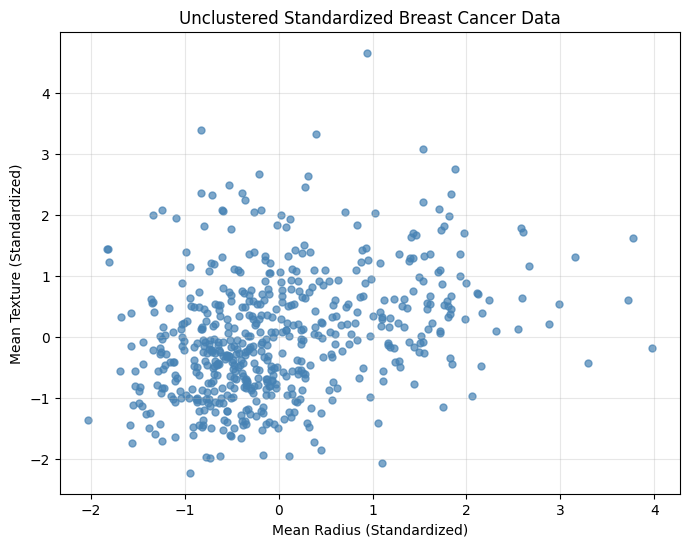

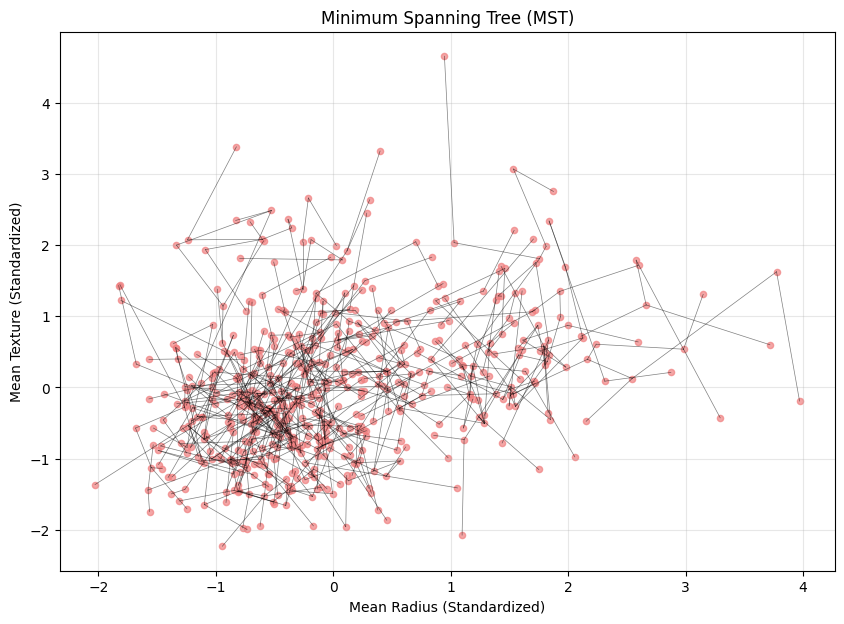

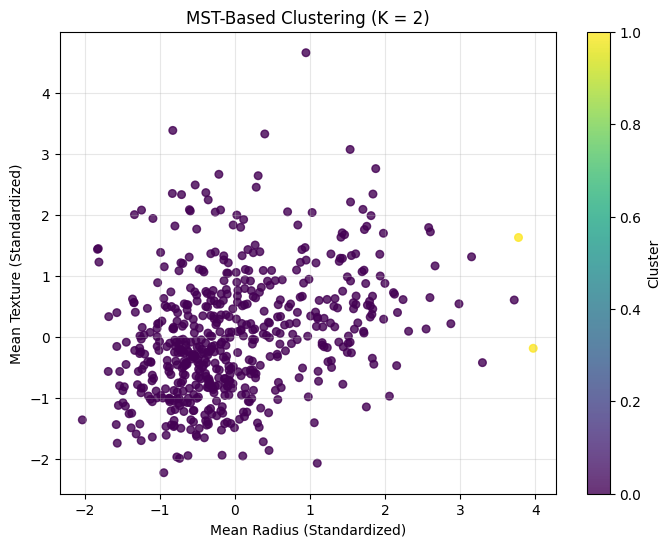

In [ ]:
# Task 8: Visualize MST and Graph-Based Clusters

# Select two representative features
feature_x = 'mean radius'
feature_y = 'mean texture'

# Get feature indices
x_index = list(X.columns).index(feature_x)
y_index = list(X.columns).index(feature_y)

# Extract standardized feature values
x_values = X_scaled[:, x_index]
y_values = X_scaled[:, y_index]


# ---------------------------------------------------------
# Plot 1: Unclustered Standardized Data
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    x_values,
    y_values,
    c='steelblue',
    s=25,
    alpha=0.7
)

plt.xlabel('Mean Radius (Standardized)')
plt.ylabel('Mean Texture (Standardized)')
plt.title('Unclustered Standardized Breast Cancer Data')
plt.grid(alpha=0.3)

plt.show()


# ---------------------------------------------------------
# Plot 2: Minimum Spanning Tree
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# Plot the data points
plt.scatter(
    x_values,
    y_values,
    c='lightcoral',
    s=20,
    alpha=0.7
)

# Draw MST edges
for u, v in MST.edges():
    plt.plot(
        [x_values[u], x_values[v]],
        [y_values[u], y_values[v]],
        color='black',
        linewidth=0.5,
        alpha=0.5
    )

plt.xlabel('Mean Radius (Standardized)')
plt.ylabel('Mean Texture (Standardized)')
plt.title('Minimum Spanning Tree (MST)')
plt.grid(alpha=0.3)

plt.show()


# ---------------------------------------------------------
# Plot 3: Final MST-Based Clusters
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

# Plot clusters using different colors
scatter = plt.scatter(
    x_values,
    y_values,
    c=cluster_labels,
    cmap='viridis',
    s=30,
    alpha=0.8
)

plt.xlabel('Mean Radius (Standardized)')
plt.ylabel('Mean Texture (Standardized)')
plt.title('MST-Based Clustering (K = 2)')

# Add colorbar
colorbar = plt.colorbar(scatter)
colorbar.set_label('Cluster')

plt.grid(alpha=0.3)

plt.show()


# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.